In [9]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import os

from pyarrow import feather

In [10]:
ITEM_ID = 26008           # Example item_id from sample_head.csv
STORE_ID = 6269        # Example store_id from sample_head.csv
DATA_PATH = '../dataset/data_andre.feather' # Adjust path if needed
TARGET_COL = 'value'
DATE_COL = 'date'

N_FORECAST = 1 
N_LOOKBACK = 30
N_FUTURE = 365
EPOCHS = 100           # Increased epochs for better convergence
BATCH_SIZE = 32
LEARNING_RATE = 0.001
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cuda


In [11]:
# -----------------------------------------------------------------------------
# DATA LOADING & PREPROCESSING
# -----------------------------------------------------------------------------
DATA_PATH = '../dataset/subset_set.feather'  # Adjust path if needed
print(f"Loading data from {DATA_PATH}...")
# Use pd.read_feather instead of feather.read_table to get a DataFrame directly
df_full = pd.read_feather(DATA_PATH)

print(f"Filtering for Item: {ITEM_ID}, Store: {STORE_ID}...")
# Filter for specific item and store
df = df_full[(df_full['item_id'] == ITEM_ID) & (df_full['store_id'] == STORE_ID)].copy()

# Fix: Check if date is in index and recover it if necessary
if DATE_COL not in df.columns and (df.index.name == DATE_COL or isinstance(df.index, pd.DatetimeIndex)):
    print(f"Recovering {DATE_COL} from index...")
    df = df.reset_index()
else:
    # Just reset the numeric index from the filtering, but keep columns
    df = df.reset_index(drop=True)

# Ensure date is datetime and sort
if DATE_COL in df.columns:
    df[DATE_COL] = pd.to_datetime(df[DATE_COL])
    df = df.sort_values(DATE_COL)
else:
    print(f"Error: {DATE_COL} column not found in dataset. Columns are: {df.columns.tolist()}")

# CHECK FOR FLATLINE IN DATA
print("\n--- DATA INSPECTION ---")
print("Last 20 values of the target column:")
print(df[TARGET_COL].tail(20).values)

# Prepare target variable
# Using 'value' as the target (sales/demand)
y = df[TARGET_COL].ffill().values.reshape(-1, 1)

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaler = scaler.fit(y)
y_scaled = scaler.transform(y)

Loading data from ../dataset/subset_set.feather...
Filtering for Item: 26008, Store: 6269...
Recovering date from index...

--- DATA INSPECTION ---
Last 20 values of the target column:
[100  81 108  91  61  61  64  89 105  68  31  23  41  38  84 134  90  79
  60  66]


In [12]:
df.head()

,date,item_id,value,cat_label,sdep_label,dep_label,dmn_label,promo_type_FRPG,promo_value_FRPG,promo_type_GAS,...,promo_value_DISC,promo_type_CIRC,promo_value_CIRC,promo_type_CIRE,promo_value_CIRE,promo_type_CLCP,promo_value_CLCP,promo_type_LFPE,promo_value_LFPE,store_id
0,2021-01-23,26008,104,sprd btr mrgrn,pos subd dairy other,pos dept dairy,other dairy,0,0.0,0,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,6269
1,2021-01-24,26008,118,sprd btr mrgrn,pos subd dairy other,pos dept dairy,other dairy,0,0.0,0,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,6269
2,2021-01-25,26008,116,sprd btr mrgrn,pos subd dairy other,pos dept dairy,other dairy,0,0.0,0,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,6269
3,2021-01-26,26008,51,sprd btr mrgrn,pos subd dairy other,pos dept dairy,other dairy,0,0.0,0,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,6269
4,2021-01-27,26008,91,sprd btr mrgrn,pos subd dairy other,pos dept dairy,other dairy,0,0.0,0,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,6269


In [ ]:
# -----------------------------------------------------------------------------
# DATA SPLITTING
# -----------------------------------------------------------------------------
# Define split sizes
# Usually 500 train, 100 val. Test is whatever is left.
n_train = 500
n_val = 100
n_test = len(y_scaled) - n_train - n_val 

print(f"Splitting data: Train={n_train}, Validation={n_val}, Test={n_test}")

# Ensure the split adds up
assert n_train + n_val + n_test == len(y_scaled), f"Split sizes ({n_train}+{n_val}+{n_test}={n_train+n_val+n_test}) must equal total samples ({len(y_scaled)})"

# Split indices
train_data = y_scaled[:n_train]
val_data = y_scaled[n_train:n_train+n_val]
test_data = y_scaled[n_train+n_val:]

# Helper function to create sequences
def create_sequences(data, lookback):
    X, Y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        Y.append(data[i])
    return np.array(X), np.array(Y)

X_train, Y_train = create_sequences(train_data, N_LOOKBACK)

val_extended = np.concatenate((train_data[-N_LOOKBACK:], val_data))
X_val, Y_val = create_sequences(val_extended, N_LOOKBACK)


print(f"Train shapes: X={X_train.shape}, Y={Y_train.shape}")
print(f"Val shapes:   X={X_val.shape}, Y={Y_val.shape}")
print(f"Test shapes:  X={X_test.shape}, Y={Y_test.shape}")

# Convert to Tensors
X_train_tensor = torch.from_numpy(X_train).float().to(DEVICE)
Y_train_tensor = torch.from_numpy(Y_train).float().to(DEVICE)

X_val_tensor = torch.from_numpy(X_val).float().to(DEVICE)
Y_val_tensor = torch.from_numpy(Y_val).float().to(DEVICE)



# Create DataLoaders
train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = TensorDataset(X_val_tensor, Y_val_tensor)
# val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

Splitting data: Train=500, Validation=100, Test=161
Train shapes: X=(470, 30, 1), Y=(470, 1)
Val shapes:   X=(100, 30, 1), Y=(100, 1)
Test shapes:  X=(161, 30, 1), Y=(161, 1)


In [14]:
class SimpleLSTM(nn.Module):
    
    def __init__(self, input_size: int = 1, hidden_size: int = 128, 
                 forecast_horizon: int = None, dropout: float = 0.2):

        super(SimpleLSTM, self).__init__()
        
        self.hidden_size = hidden_size
        #self.num_layers = num_layers
        self.input_size = input_size
        
        # LSTM layer
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            #num_layers=num_layers,
            #dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )
        
        # Output layer: predict single next value
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        out, (hn, cn) = self.lstm(x)
        last_out = out[:, -1, :]
        
        return self.fc(last_out)

Starting training with Recursive Regularization...


Epoch [10/100], Train Loss: 0.0100, Val MSE: 0.0019, Val Pred StdDev: 0.0014
Epoch [20/100], Train Loss: 0.0090, Val MSE: 0.0035, Val Pred StdDev: 0.0078
Epoch [30/100], Train Loss: 0.0086, Val MSE: 0.0018, Val Pred StdDev: 0.0073
Epoch [40/100], Train Loss: 0.0085, Val MSE: 0.0013, Val Pred StdDev: 0.0044
Epoch [50/100], Train Loss: 0.0083, Val MSE: 0.0018, Val Pred StdDev: 0.0001
Epoch [60/100], Train Loss: 0.0079, Val MSE: 0.0018, Val Pred StdDev: 0.0093
Epoch [70/100], Train Loss: 0.0079, Val MSE: 0.0019, Val Pred StdDev: 0.0091
Epoch [80/100], Train Loss: 0.0087, Val MSE: 0.0038, Val Pred StdDev: 0.0090
Epoch [90/100], Train Loss: 0.0079, Val MSE: 0.0013, Val Pred StdDev: 0.0042
Epoch [100/100], Train Loss: 0.0079, Val MSE: 0.0022, Val Pred StdDev: 0.0135


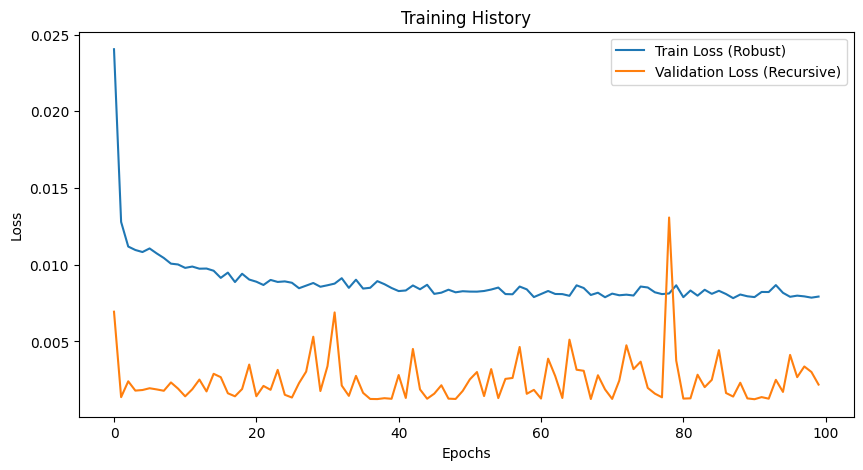

In [15]:
# Initialize model, loss, optimizer
model = SimpleLSTM(input_size=1, hidden_size=64).to(DEVICE) # Ensure hidden_size matches model def
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

# -----------------------------------------------------------------------------
# TRAINING LOOP WITH RECURSIVE REGULARIZATION
# -----------------------------------------------------------------------------
train_losses = []
val_recursive_losses = [] 

print("Starting training with Recursive Regularization...")

for epoch in range(EPOCHS):
    model.train()
    epoch_train_loss = 0
    
    for batch_X, batch_Y in train_loader:
        # batch_X shape: (batch_size, lookback, 1)
        # batch_Y shape: (batch_size, 1) -> This is the target for the *next* step
        
        optimizer.zero_grad()
        
        # 1. Standard One-Step Prediction
        # -----------------------------
        outputs = model(batch_X)
        loss_1 = criterion(outputs, batch_Y.view(-1, 1))
        
        # 2. Recursive Step (Regularization)
        # -----------------------------
        # Use the prediction 'outputs' to simulate the next input step
        # We need to construct the input for t+2 used in training
        # This is tricky without loading t+2 data in the loader. 
        # SIMPLER APPROACH: Just add noise to input to robustify against "drift"
        
        # Add noise to input during training to simulate recursive error
        # Effectively "Denoising Autoencoder" style training for robustness
        noise = torch.randn_like(batch_X) * 0.05 # Increased noise level
        outputs_noisy = model(batch_X + noise)
        loss_2 = criterion(outputs_noisy, batch_Y.view(-1, 1))
        
        # Total loss
        loss = loss_1 + loss_2
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_train_loss += loss.item()
        
    train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(train_loss)
    
    # ------------------
    # VALIDATION (Recursive)
    # ------------------
    model.eval()
    val_preds = []
    
    current_input = train_data[-N_LOOKBACK:].reshape(1, N_LOOKBACK, 1)
    current_input_tensor = torch.from_numpy(current_input).float().to(DEVICE)
    
    # Check if we are flatlining by printing std dev of predictions occasionally
    with torch.no_grad():
        for i in range(n_val):
            pred = model(current_input_tensor)
            pred_value = pred.item()
            val_preds.append(pred_value)
            
            next_input = torch.cat((current_input_tensor[:, 1:, :], pred.unsqueeze(1)), dim=1)
            current_input_tensor = next_input
            
    val_preds = np.array(val_preds)
    val_mse = np.mean((val_preds - val_data.flatten())**2)
    val_recursive_losses.append(val_mse)
    
    if (epoch + 1) % 10 == 0:
        val_std = np.std(val_preds)
        print(f'Epoch [{epoch+1}/{EPOCHS}], Train Loss: {train_loss:.4f}, Val MSE: {val_mse:.4f}, Val Pred StdDev: {val_std:.4f}')

# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss (Robust)')
plt.plot(val_recursive_losses, label='Validation Loss (Recursive)')
plt.title('Training History')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

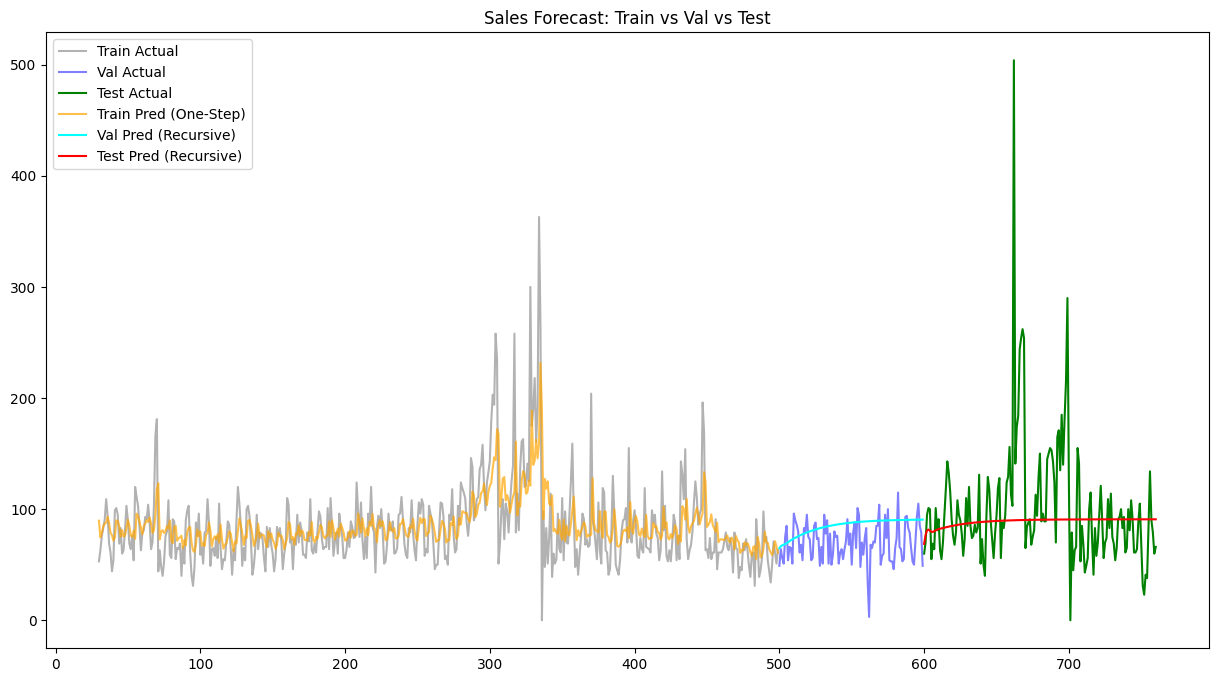

NameError: name 'mean_squared_error' is not defined

In [ ]:
# -----------------------------------------------------------------------------
# EVALUATION (RECURSIVE)
# -----------------------------------------------------------------------------
model.eval()

# Helper function to get recursive predictions
def get_recursive_predictions(model, initial_input, n_steps):
    preds = []
    curr = initial_input.clone()
    with torch.no_grad():
        for _ in range(n_steps):
            pred = model(curr.unsqueeze(0))
            pred_val = pred.item()
            preds.append(pred_val)
            new_row = torch.tensor([[pred_val]], device=DEVICE)
            curr = torch.cat((curr[1:], new_row), dim=0)
    return np.array(preds).reshape(-1, 1)

# 1. Train Predictions (One-Step Ahead for visualization on training set)
train_preds = []
model.eval()
with torch.no_grad():
    for i in range(len(X_train)):
        pred = model(torch.from_numpy(X_train[i]).float().unsqueeze(0).to(DEVICE))
        train_preds.append(pred.item())
train_preds_array = np.array(train_preds).reshape(-1, 1)
train_preds_inv = scaler.inverse_transform(train_preds_array)
train_actuals_inv = scaler.inverse_transform(Y_train.reshape(-1, 1))

# 2. Validation Predictions (Recursive)
# Start validation recursion with the last window of training data
val_init_input = torch.from_numpy(train_data[-N_LOOKBACK:]).float().to(DEVICE)
val_preds_array = get_recursive_predictions(model, val_init_input, n_val)
val_preds_inv = scaler.inverse_transform(val_preds_array)
val_actuals_inv = scaler.inverse_transform(val_data.reshape(-1, 1))

# 3. Test Predictions (Recursive)
# Start test recursion with the last window of validation data
test_init_input = torch.from_numpy(val_data[-N_LOOKBACK:]).float().to(DEVICE)
test_preds_array = get_recursive_predictions(model, test_init_input, len(Y_test))
test_preds_inv = scaler.inverse_transform(test_preds_array)
test_actuals_inv = scaler.inverse_transform(Y_test.reshape(-1, 1))

# --- PLOTTING ---
plt.figure(figsize=(15, 8))

# Construct full timelines
train_range = range(N_LOOKBACK, n_train) # Aligned with X_train
val_range = range(n_train, n_train+n_val)
test_range = range(n_train+n_val, n_train+n_val+len(Y_test))

# Plot Actuals (Full Series)
# We need to stitch 'em together or just plot distinct segments
plt.plot(train_range, train_actuals_inv, label='Train Actual', color='black', alpha=0.3)
plt.plot(val_range, val_actuals_inv, label='Val Actual', color='blue', alpha=0.5)
plt.plot(test_range, test_actuals_inv, label='Test Actual', color='green')

# Plot Predictions
plt.plot(train_range, train_preds_inv, label='Train Pred (One-Step)', color='orange', alpha=0.7)
plt.plot(val_range, val_preds_inv, label='Val Pred (Recursive)', color='cyan')
plt.plot(test_range, test_preds_inv, label='Test Pred (Recursive)', color='red')

plt.title('Sales Forecast: Train vs Val vs Test')
plt.legend()
plt.show()

# Detail plot for Test
plt.figure(figsize=(12, 6))
plt.plot(test_actuals_inv, label='Actual Sales', color='green')
plt.plot(test_preds_inv, label='Recursive Predictions', color='red', linestyle='--')
plt.title('Test Set Detail (Recursive)')
plt.legend()
plt.show()